# Calendar features

Calendar features serve as key elements in time series forecasting. These features decompose date and time into basic units such as year, month, day, weekday, etc., allowing models to identify recurring patterns, understand seasonal variations, and capture trends. Calendar features can be used as [exogenous variables](../user_guides/exogenous-variables.html) because they are known for the period for which predictions are being made (the forecast horizon).

**Dates and time in Pandas**

Pandas provides a comprehensive set of capabilities tailored for handling time series data in various domains. Using the NumPy `datetime64` and `timedelta64` data types, Pandas combines a wide range of functionality from various Python libraries while introducing a wealth of novel tools to effectively manipulate time series data. This includes:

+ Easily parse date and time data from multiple sources and formats.

+ Generate sequences of fixed-frequency dates and time spans.

+ Streamline the manipulation and conversion of date-time information, including time zones.

+ Facilitate the resampling or conversion of time series data to specific frequencies.

For an in-depth exploration of Pandas' comprehensive time series and date capabilities, please refer to this [resource](https://pandas.pydata.org/docs/user_guide/timeseries.html).

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>


 <p>
Since version <code>0.23.0</code>, users can introduce calendar features into the forecasters using two approaches:
</p>
<ul>
<li>
    Using the <code>calendar_features</code> argument: passing a <code>CalendarFeatures</code> into the <code>calendar_features</code> argument makes it straightforward to incorporate and encode calendar features directly into the forecasting pipeline without any external preprocessing. Furthermore, the forecaster will automatically generate these features during the predict phase, meaning users do not need to pass them manually.
</li>

<li>
    Using the <code>exog</code> argument: In this case, users must create and encode the calendar features externally before passing them to the forecaster during the fit and predict phases.
</li>
</ul>
</div>

## Libraries and data

In [1]:
# Libraries
# ==============================================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from astral import LocationInfo
from astral.sun import sun

from lightgbm import LGBMRegressor
from skforecast.datasets import fetch_dataset
from skforecast.recursive import ForecasterRecursive
from skforecast.preprocessing import CalendarFeatures, calculate_distance_from_holiday

In [2]:
# Downloading data
# ==============================================================================
data = fetch_dataset(name="bike_sharing", raw=True)
data = data[['date_time', 'users']]
data.head()

╭───────────────────────────────── bike_sharing ──────────────────────────────────╮
│ Description:                                                                    │
│ Hourly usage of the bike share system in the city of Washington D.C. during the │
│ years 2011 and 2012. In addition to the number of users per hour, information   │
│ about weather conditions and holidays is available.                             │
│                                                                                 │
│ Source:                                                                         │
│ Fanaee-T,Hadi. (2013). Bike Sharing Dataset. UCI Machine Learning Repository.   │
│ https://doi.org/10.24432/C5W894.                                                │
│                                                                                 │
│ URL:                                                                            │
│ https://raw.githubusercontent.com/skforecast/skforecast-                        │
│ datasets/main/data/bike_sharing_dataset_clean.csv                               │
│                                                                                 │
│ Shape: 17544 rows x 12 columns                                                  │
╰─────────────────────────────────────────────────────────────────────────────────╯

,date_time,users
0,2011-01-01 00:00:00,16.0
1,2011-01-01 01:00:00,40.0
2,2011-01-01 02:00:00,32.0
3,2011-01-01 03:00:00,13.0
4,2011-01-01 04:00:00,1.0


To take advantage of the date-time functionality offered by Pandas, the column of interest must be stored as `datetime`. Although not required, it is recommended to set it as an index for further integration with skforecast.

In [3]:
# Preprocess data
# ==============================================================================
data['date_time'] = pd.to_datetime(data['date_time'], format='%Y-%m-%d %H:%M:%S')
data = data.set_index('date_time')
data = data.sort_index()
data = data.asfreq('h')
data.head()

,users
date_time,
2011-01-01 00:00:00,16.0
2011-01-01 01:00:00,40.0
2011-01-01 02:00:00,32.0
2011-01-01 03:00:00,13.0
2011-01-01 04:00:00,1.0


## Extract calendar features

A calendar feature is simply a component extracted from the datetime index. Pandas exposes each one through the `.index` accessors, for example `.month`, `.hour`, `.day_of_week`, or `.isocalendar().week`. As a quick illustration, the month and hour of the first observations:

In [4]:
# A calendar feature is just a component of the datetime index
# ==============================================================================
# These accessors are shown for illustration only; the values are not stored
# back into `data` to keep the DataFrame clean for the rest of the guide.
pd.DataFrame(
    {'month': data.index.month, 'hour': data.index.hour},
    index = data.index,
).head()

,month,hour
date_time,,
2011-01-01 00:00:00,1,0
2011-01-01 01:00:00,1,1
2011-01-01 02:00:00,1,2
2011-01-01 03:00:00,1,3
2011-01-01 04:00:00,1,4


Extracting each component by hand quickly becomes repetitive. Instead, `CalendarFeatures` in `skforecast.preprocessing` wraps these same Pandas accessors and generates all the requested features (optionally encoded) in a single call. Available features include:

+ `year`, `quarter`, `month`, `week`
+ `day_of_year`, `day_of_month`, `day_of_week`
+ `hour`, `minute`, `second`
+ `weekend` (boolean flag)

The example below extracts `month`, `week`, `day_of_week`, and `hour` with `encoding=None`, so the raw integer components are returned.

In [5]:
# Create calendar features with skforecast's CalendarFeatures
# ==============================================================================
calendar_transformer = CalendarFeatures(
    features              = ['month', 'week', 'day_of_week', 'hour'],
    encoding              = None,
    keep_original_columns = True,
)

calendar_features = calendar_transformer.fit_transform(data)
calendar_features.head()

,users,month,week,day_of_week,hour
date_time,,,,,
2011-01-01 00:00:00,16.0,1,52,5,0
2011-01-01 01:00:00,40.0,1,52,5,1
2011-01-01 02:00:00,32.0,1,52,5,2
2011-01-01 03:00:00,13.0,1,52,5,3
2011-01-01 04:00:00,1.0,1,52,5,4


## Using calendar features in a forecaster

Calendar features can be plugged into a forecaster in two ways:

+ **Delegated**: pass a `CalendarFeatures` instance to the forecaster's `calendar_features` argument. The forecaster builds the features automatically during both training and prediction, so no calendar `exog` needs to be created or passed at prediction time. Supported by `ForecasterRecursive`, `ForecasterRecursiveMultiSeries`, `ForecasterDirect`, and `ForecasterDirectMultiVariate`.

+ **Manual**: build the features with `CalendarFeatures.fit_transform` and pass them through the `exog` argument of `fit` and `predict`. This is the only option for forecasters that do not support `calendar_features` (e.g. `ForecasterStats`, `ForecasterRnn`, `ForecasterFoundation`).

<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">
<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

Do not use both paths for the same features. Passing <code>calendar_features</code> and adding manually-built calendar columns with the same names to <code>exog</code> raises a <code>ValueError</code> for duplicate feature names.

</div>

In [6]:
# Option A: delegated calendar features (`calendar_features` argument)
# ==============================================================================
y = data['users']
y_train = y.iloc[:-24]

calendar_transformer = CalendarFeatures(
    features = ['month', 'week', 'day_of_week', 'hour'], encoding = None
)

forecaster = ForecasterRecursive(
                 estimator         = LGBMRegressor(random_state=123, verbose=-1),
                 lags              = 24,
                 calendar_features = calendar_transformer,
             )
forecaster.fit(y=y_train)

# No calendar `exog` is passed to `predict`, the forecaster derives the
# calendar features for the forecast horizon from the datetime index itself.
predictions = forecaster.predict(steps=24)
predictions.head()

2012-12-31 00:00:00    28.218451
2012-12-31 01:00:00    14.282595
2012-12-31 02:00:00     7.573183
2012-12-31 03:00:00     5.548416
2012-12-31 04:00:00     5.505177
Freq: h, Name: pred, dtype: float64

In [7]:
# Option B: manual calendar features (`exog` argument)
# ==============================================================================
# Unlike Option A, the future calendar values must be built and passed
# explicitly, covering the full forecast horizon.
calendar_transformer = CalendarFeatures(
    features              = ['month', 'week', 'day_of_week', 'hour'], 
    encoding              = None,
    keep_original_columns = True
)

exog_calendar = calendar_transformer.fit_transform(y.index)
exog_train = exog_calendar.loc[y_train.index]
exog_test  = exog_calendar.loc[y.index[-24:]]

forecaster = ForecasterRecursive(
                 estimator = LGBMRegressor(random_state=123, verbose=-1),
                 lags      = 24
             )
forecaster.fit(y=y_train, exog=exog_train)

predictions = forecaster.predict(steps=24, exog=exog_test)
predictions.head()

2012-12-31 00:00:00    28.218451
2012-12-31 01:00:00    14.282595
2012-12-31 02:00:00     7.573183
2012-12-31 03:00:00     5.548416
2012-12-31 04:00:00     5.505177
Freq: h, Name: pred, dtype: float64

## Sunlight-Related Features

Sunlight often plays a key role in time series patterns. For example, a household's hourly electricity consumption may correlate significantly with whether it's nighttime, as more electricity is typically used for lighting during those hours. Understanding and incorporating sunlight-related characteristics into analyses can provide valuable insights into consumption patterns and behavioral trends. In addition, factors such as sunrise/sunset times, seasonal changes affecting daylight, and their influence on different datasets can provide deeper context and help predict behavioral trends, such as bike rental fluctuations. There are several Python libraries available for extracting sunrise and sunset times. Two of the most commonly used are `pvlib` and `astral`.

In [8]:
# Features based on the sunlight
# ==============================================================================

# The location is set to Washington, D.C. because the bike_sharing dataset records 
# the Capital Bikeshare system there; using the real location ensures sunrise/sunset 
# times match the period of the data.
location = LocationInfo("Washington, D.C.", "USA")

# Calculate sunlight only for unique dates
unique_dates = data.index.normalize().unique()
sun_times = [sun(location.observer, date=d, tzinfo=location.timezone) for d in unique_dates]
sunrise_times = [st['sunrise'] for st in sun_times]
sunset_times = [st['sunset'] for st in sun_times]

# Convert to Series and extract the local hour
sunrise_hours = pd.Series(sunrise_times, index=unique_dates).dt.round("h").dt.hour
sunset_hours = pd.Series(sunset_times, index=unique_dates).dt.round("h").dt.hour

# Map the unique dates back to the original hourly index
sun_light_features = pd.DataFrame(index=data.index)
sun_light_features['sunrise_hour'] = data.index.normalize().map(sunrise_hours)
sun_light_features['sunset_hour'] = data.index.normalize().map(sunset_hours)
sun_light_features['daylight_hours'] = sun_light_features['sunset_hour'] - sun_light_features['sunrise_hour']
sun_light_features.tail()

,sunrise_hour,sunset_hour,daylight_hours
date_time,,,
2012-12-31 19:00:00,8,16,8
2012-12-31 20:00:00,8,16,8
2012-12-31 21:00:00,8,16,8
2012-12-31 22:00:00,8,16,8
2012-12-31 23:00:00,8,16,8


## Feature encoding

### Cyclical encoding

Certain aspects of the calendar, such as hours of the day or days of the week, behave in cycles. For example, the hours of a day range from 0 to 23. If interpreted as a linear numerical variable, the hour of 23:00 would be 23 units away from the hour of 00:00. However, this is not true because 23:00 is only one hour away from 00:00. The same is true for the months of the year, since December is only one month away from January. Using techniques such as trigonometric functions (sine and cosine transformations) makes it possible to represent cyclic patterns and avoid inconsistencies in data representation. This technique is called cyclical encoding and can significantly improve the predictive power of models.

In [9]:
# Cyclical encoding
# ==============================================================================
# `CalendarFeatures` extracts the calendar features and encodes
# them as sine/cosine pairs in a single step.
cyclical_transformer = CalendarFeatures(
    features              = ['month', 'week', 'day_of_week', 'hour'],
    encoding              = 'cyclical',
    keep_original_columns = False,
)

cyclical_features = cyclical_transformer.fit_transform(data)
cyclical_features.head(3)

,month_sin,month_cos,week_sin,week_cos,day_of_week_sin,day_of_week_cos,hour_sin,hour_cos
date_time,,,,,,,,
2011-01-01 00:00:00,0.5,0.866025,-0.118273,0.992981,-0.974928,-0.222521,0.000000,1.000000
2011-01-01 01:00:00,0.5,0.866025,-0.118273,0.992981,-0.974928,-0.222521,0.258819,0.965926
2011-01-01 02:00:00,0.5,0.866025,-0.118273,0.992981,-0.974928,-0.222521,0.500000,0.866025


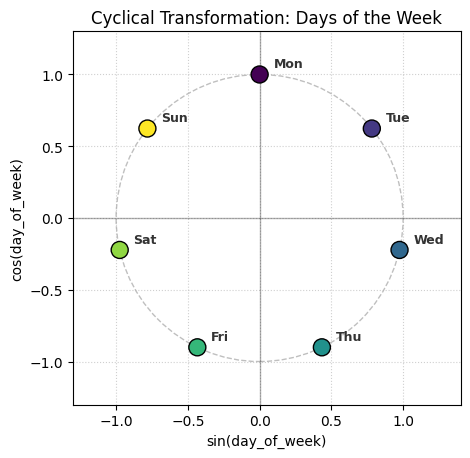

In [10]:
# Plot value of sin and cos for each day_of_week
# ==============================================================================
df_plot = pd.DataFrame({
    'day_idx': calendar_features['day_of_week'],
    'sin': cyclical_features['day_of_week_sin'],
    'cos': cyclical_features['day_of_week_cos']
})
df_unique = df_plot.drop_duplicates().sort_values('day_idx').reset_index(drop=True)
day_names = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri', 5: 'Sat', 6: 'Sun'}

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
ax.add_patch(circle)
ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)
sp = ax.scatter(
    df_unique["sin"], 
    df_unique["cos"], 
    c=df_unique["day_idx"], 
    cmap='viridis', 
    s=150, zorder=3, edgecolors='k'
)

for idx, row in df_unique.iterrows():
    day_name = day_names.get(row['day_idx'], str(row['day_idx']))
    
    ax.annotate(
        day_name, 
        (row['sin'], row['cos']), 
        textcoords="offset points", 
        xytext=(10, 5), 
        ha='left', 
        fontsize=9,
        fontweight='bold',
        color='#333333'
    )

ax.set(
    title="Cyclical Transformation: Days of the Week",
    xlabel="sin(day_of_week)",
    ylabel="cos(day_of_week)",
)
ax.grid(True, linestyle=':', alpha=0.6)
ax.set_xlim(-1.3, 1.4)
ax.set_ylim(-1.3, 1.3)
plt.show()

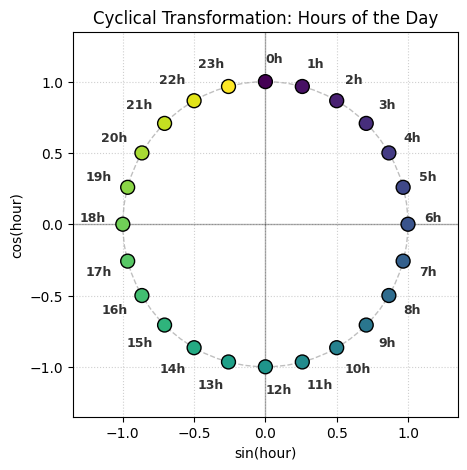

In [11]:
# Plot value of sin and cos for each hour
# ==============================================================================
df_plot = pd.DataFrame({
    'hour_idx': calendar_features['hour'],
    'sin': cyclical_features['hour_sin'],
    'cos': cyclical_features['hour_cos']
})

df_unique = df_plot.drop_duplicates().sort_values('hour_idx').reset_index(drop=True)

fig, ax = plt.subplots(figsize=(5, 5))
ax.set_aspect('equal')
circle = plt.Circle((0, 0), 1, color='gray', fill=False, linestyle='--', alpha=0.5)
ax.add_patch(circle)
ax.axhline(0, color='black', linewidth=1, alpha=0.3)
ax.axvline(0, color='black', linewidth=1, alpha=0.3)

sp = ax.scatter(
    df_unique["sin"], 
    df_unique["cos"], 
    c=df_unique["hour_idx"], 
    cmap='viridis', 
    s=100, zorder=3, edgecolors='k'
)

for idx, row in df_unique.iterrows():
    hour_label = f"{int(row['hour_idx'])}h"
    x = row['sin']
    y = row['cos']
    x_offset = x * 12
    y_offset = y * 12
    ha = 'left' if x >= 0 else 'right'
    va = 'bottom' if y >= 0 else 'top'
    
    ax.annotate(
        hour_label, 
        (x, y), 
        textcoords="offset points", 
        xytext=(x_offset, y_offset),
        ha=ha, 
        va=va,
        fontsize=9,
        fontweight='bold',
        color='#333333'
    )

ax.set(
    title="Cyclical Transformation: Hours of the Day",
    xlabel="sin(hour)",
    ylabel="cos(hour)",
)
ax.grid(True, linestyle=':', alpha=0.6)

ax.set_xlim(-1.35, 1.35)
ax.set_ylim(-1.35, 1.35)
plt.show()

### Other encodings (one-hot and spline)

Beyond cyclical (sin/cos), `CalendarFeatures` supports two other encodings for calendar features:

+ `'onehot'`: one column per known category (e.g. `month_1`, `month_2`, ..., `month_12`). The schema is stable across training and prediction: the leap-year column `day_of_year_366` and the ISO week 53 column are always present, even if those values do not appear in the data.

+ `'spline'`: smooth periodic B-splines, with approximately `max_value` columns per feature. A dense alternative to one-hot, useful when the model benefits from a smooth signal but the cyclical (2-column) representation is too compact. Particularly suited for high-cardinality features such as `day_of_year` or `day_of_month`.

In [12]:
# One-hot encoding
# ==============================================================================
onehot_transformer = CalendarFeatures(
    features              = ['day_of_week'],
    encoding              = 'onehot',
    keep_original_columns = False,
)
onehot_features = onehot_transformer.fit_transform(data)
onehot_features.head(3)

,day_of_week_0,day_of_week_1,day_of_week_2,day_of_week_3,day_of_week_4,day_of_week_5,day_of_week_6
date_time,,,,,,,
2011-01-01 00:00:00,0,0,0,0,0,1,0
2011-01-01 01:00:00,0,0,0,0,0,1,0
2011-01-01 02:00:00,0,0,0,0,0,1,0


In [13]:
# Spline encoding
# ==============================================================================
spline_transformer = CalendarFeatures(
    features              = ['day_of_week'],
    encoding              = 'spline',
    keep_original_columns = False,
)
spline_features = spline_transformer.fit_transform(data)
spline_features.head(3)

,day_of_week_sp_0,day_of_week_sp_1,day_of_week_sp_2,day_of_week_sp_3,day_of_week_sp_4,day_of_week_sp_5,day_of_week_sp_6
date_time,,,,,,,
2011-01-01 00:00:00,0.166667,0.0,0.0,0.0,0.0,0.166667,0.666667
2011-01-01 01:00:00,0.166667,0.0,0.0,0.0,0.0,0.166667,0.666667
2011-01-01 02:00:00,0.166667,0.0,0.0,0.0,0.0,0.166667,0.666667


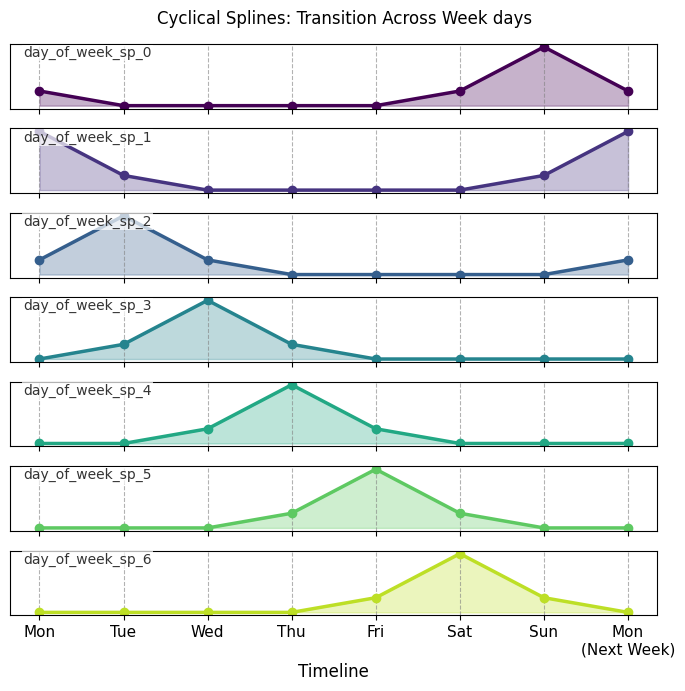

In [14]:
# Plot: Spline Basis Functions
# ==============================================================================
df_plot = spline_features.copy()
df_plot['day_idx'] = calendar_features['day_of_week'].values
df_unique = df_plot.drop_duplicates(subset=['day_idx']).sort_values('day_idx').reset_index(drop=True)

first_row = df_unique.iloc[[0]].copy()
first_row['day_idx'] = 7  # Give it a temporary index of 7 for plotting at the end
df_wrapped = pd.concat([df_unique, first_row], ignore_index=True)
spline_cols = [col for col in df_unique.columns if col != 'day_idx']
n_splines = len(spline_cols)
day_names_wrapped = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun', 'Mon\n(Next Week)']


fig, axes = plt.subplots(
    nrows=n_splines, ncols=1, 
    figsize=(7, 1 * n_splines), 
    sharex=True, sharey=True 
)
axes = np.atleast_1d(axes)
colors = plt.cm.viridis(np.linspace(0, 0.9, n_splines))

for i, (col, ax) in enumerate(zip(spline_cols, axes)):
    ax.plot(
        df_wrapped['day_idx'], 
        df_wrapped[col], 
        marker='o', markersize=6, linewidth=2.5, color=colors[i]
    )
    ax.fill_between(
        df_wrapped['day_idx'], df_wrapped[col], alpha=0.3, color=colors[i]
    )
    ax.set_yticks([])
    ax.set_ylabel("")
    ax.text(
        0.02, 0.8, col, 
        transform=ax.transAxes, 
        fontsize=10, color='#333333',
        bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1)
    )
    ax.xaxis.grid(True, linestyle='--', alpha=0.6, color='gray')
    ax.yaxis.grid(False)

fig.suptitle("Cyclical Splines: Transition Across Week days")
axes[-1].set_xticks(df_wrapped['day_idx'])
axes[-1].set_xticklabels(day_names_wrapped, fontsize=11)
axes[-1].set_xlabel("Timeline", fontsize=12)

plt.tight_layout()
plt.show()

<div class="admonition note" name="html-admonition" style="background: rgba(0,191,191,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00bfa5; border-color: #00bfa5; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00bfa5;"></i>
    <b style="color: #00bfa5;">&#128161 Tip</b>
</p>
For users who prefer more granular control by applying feature extraction and encoding as two separate steps, the <a href="https://feature-engine.trainindata.com/en/latest/user_guide/datetime/DatetimeFeatures.html#datetime-features">DatetimeFeatures</a> and <a href="https://feature-engine.trainindata.com/en/latest/user_guide/creation/CyclicalFeatures.html">CyclicalFeatures</a> classes from the <a href="https://feature-engine.trainindata.com/">feature_engine</a> library are a good alternative. Both are fully compatible with skforecast.

</div>

## Distance to holidays

Many time series exhibit patterns related to holidays. Bike rentals drop on public holidays, retail sales spike before them, and flight bookings change around bank holidays. Beyond a binary "is holiday" flag, models often benefit from knowing **how far** an observation is from the nearest holiday. The `calculate_distance_from_holiday` function in `skforecast.preprocessing` produces two features:

+ `time_to_holiday`: number of periods until the next holiday.

+ `time_since_holiday`: number of periods since the last holiday.

The time unit is inferred from the index frequency. For the bike sharing dataset, which is sampled hourly, the values are expressed in hours.

In [15]:
# Distance to next / since last holiday
# ==============================================================================
# Reload the dataset to keep the `holiday` column (it was dropped earlier).
data_holiday = fetch_dataset(name='bike_sharing', raw=True, verbose=False)
data_holiday['date_time'] = pd.to_datetime(
    data_holiday['date_time'], format='%Y-%m-%d %H:%M:%S'
)
data_holiday = (
    data_holiday
    .set_index('date_time')
    .sort_index()
    .asfreq('h')
)

holiday_features = calculate_distance_from_holiday(
    X              = data_holiday[['holiday']],
    holiday_column = 'holiday',
    fill_na        = 0,
)
holiday_features.head()

,time_to_holiday,time_since_holiday
date_time,,
2011-01-01 00:00:00,384,0
2011-01-01 01:00:00,383,0
2011-01-01 02:00:00,382,0
2011-01-01 03:00:00,381,0
2011-01-01 04:00:00,380,0


<div class="admonition note" name="html-admonition" style="background: rgba(0,184,212,.1); padding-top: 0px; padding-bottom: 6px; border-radius: 8px; border-left: 8px solid #00b8d4; border-color: #00b8d4; padding-left: 10px; padding-right: 10px;">

<p class="title">
    <i style="font-size: 18px; color:#00b8d4;"></i>
    <b style="color: #00b8d4;">✏️ Note</b>
</p>

See <a href="../faq/cyclical-features-time-series.html" target="_blank">Cyclical features in time series forecasting</a> for a more detailed description of strategies for encoding cyclic features.

</div>